# Customer Churn Prediction — ANN Model

# Objective
Build an Artificial Neural Network to predict whether a telecom
customer will churn based on their usage patterns and account information.

# Approach
1. Data Preprocessing
2. Feature Engineering
3. Build ANN Model
4. Evaluate Model Performance
5. Save Model for Deployment

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ANN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, accuracy_score
)

# Saving
import joblib

In [2]:
# Load Dataset
BASE_DIR = Path().resolve()
df = pd.read_csv(BASE_DIR / "data" / "Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Preprocessing

# (A) Handle TotalCharges Column
TotalCharges is stored as string in raw data — converting to numeric.
Some rows have empty TotalCharges — filling with median value.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# (B) Drop Unnecessary Columns
CustomerID is a unique identifier and has no role in predicting The Churn Rates.
Dropping it to avoid noise in model training.

In [4]:
df = df.drop('customerID', axis=1)
print("Columns after dropping CustomerID:", df.shape[1])

Columns after dropping CustomerID: 20


# (C) Encoding Categorical Variables

Binary columns (Yes/No, Male/Female) → Label Encoding
Multi-category columns (Contract, PaymentMethod) → One Hot Encoding

One Hot Encoding prevents model from assuming ordinal
relationship between categories.


In [5]:
le = LabelEncoder()
binary = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]
for col in binary:
    df[col] = le.fit_transform(df[col])


df = pd.get_dummies(
    df,
    columns=[
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaymentMethod'
    ],
    drop_first=True
)

print("Dataset Shape after encoding:", df.shape)

Dataset Shape after encoding: (7043, 31)


# (D) Feature Importance Analysis
Using Random Forest to identify which features contribute 
most to churn prediction before building ANN.
Top features will help understand the data better.

                                  Feature  Importance
8                            TotalCharges    0.198587
4                                  tenure    0.175923
7                          MonthlyCharges    0.167846
11            InternetService_Fiber optic    0.039383
28         PaymentMethod_Electronic check    0.038892
0                                  gender    0.028211
26                      Contract_Two year    0.026361
6                        PaperlessBilling    0.025463
14                     OnlineSecurity_Yes    0.024631
20                        TechSupport_Yes    0.023627
2                                 Partner    0.022815
25                      Contract_One year    0.021879
16                       OnlineBackup_Yes    0.021218
1                           SeniorCitizen    0.020311
10                      MultipleLines_Yes    0.020311
3                              Dependents    0.019424
18                   DeviceProtection_Yes    0.019037
22                        St

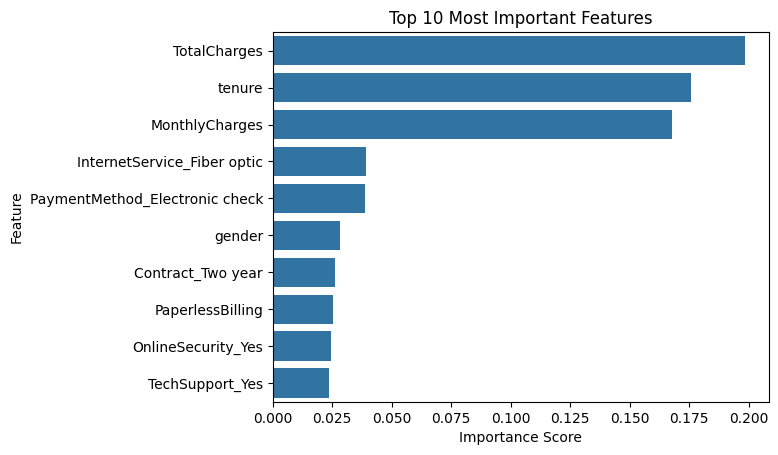

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


# (E) Train Test Split

80% training data — 20% test data
random_state=42 for reproducibility


In [7]:
X = df.drop(columns=['Churn'])
y = df['Churn'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# (F) SMOTE Experiment — Handling Class Imbalance
Dataset is imbalanced at 73.5% vs 26.5%.
Testing SMOTE to see if it improves model performance.

In [8]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print("No Churn:", sum(y_train == 0))
print("Churn:", sum(y_train == 1))

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("No Churn:", sum(y_train_smote == 0))
print("Churn:", sum(y_train_smote == 1))

Before SMOTE:
No Churn: 4138
Churn: 1496

After SMOTE:
No Churn: 4138
Churn: 4138


# SMOTE Experiment — Handling Class Imbalance

Dataset is imbalanced at 73.5% vs 26.5%.
Tested SMOTE to check if it improves model performance.

# Results Comparison:

| Metric | Without SMOTE | With SMOTE |
|--------|--------------|------------|
| Accuracy | 77.9% | 77.3% |
| Precision | 0.5638 | 0.5527 |
| Recall | 0.7346 | 0.7587 |
| F1 Score | 0.638 | 0.6395 |
| AUC ROC | 0.8507 | 0.8578 |

# Proceeded WITHOUT SMOTE

Reasons:
- Accuracy is better without SMOTE (77.9% vs 77.3%)
- Precision is better without SMOTE (0.56 vs 0.55)
- F1 Score is almost same in both cases
- AUC ROC difference is very small (0.001)
- SMOTE improved Recall slightly but reduced
  Precision and Accuracy
- Overall balanced performance is better without SMOTE

This experiment shows that blindly applying techniques
without comparing results might leads to wrong decisions.

# (G) Feature Scaling — StandardScaler

ANN uses gradient descent for training.
Features with different scales cause unstable gradients
and slower convergence.
StandardScaler normalizes all features to same range, mean=0 and std=1
for stable and faster training. Scaler fitted ONLY on training data to prevent
data leakage.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. ANN Architecture

# Design:
- Input neurons: 30 (equal to number of features after preprocessing)
- Hidden Layer 1: 64 neurons — ReLU activation
- Hidden Layer 2: 32 neurons — ReLU activation
- Hidden Layer 3: 16 neurons — ReLU activation
- Output Layer: 1 neuron — Sigmoid activation

# Why ReLU for hidden layers:
Avoids vanishing gradient problem, computationally efficient
and enables faster convergence.

# Why Sigmoid for output:
Outputs probability between 0 and 1, perfect for binary
classification problem.

# Regularization:
- L2 regularization (0.001) prevents overfitting
- Dropout (0.3) reduces co-adaptation of neurons

# Optimizer: Adam
Combines Momentum and RMSProp advantages.
Automatically adapts learning rate for each parameter.

# Loss Function: Binary Cross Entropy
Specifically designed for binary classification.
Penalizes confident wrong predictions more heavily.

In [10]:
model = Sequential()
model.add(Dense(
    64,
    activation='relu',
    input_dim=X_train.shape[1],
    kernel_initializer='he_uniform',
    kernel_regularizer=l2(0.001)
))
model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation='relu',
    kernel_initializer='he_uniform',
    kernel_regularizer=l2(0.001)
))
model.add(Dropout(0.3))

model.add(Dense(
    16,
    activation='relu',
    kernel_initializer='he_uniform',
    kernel_regularizer=l2(0.001)
))
model.add(Dropout(0.3))

model.add(Dense(
    1,
    activation='sigmoid'
))

model.summary()


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Model Training

# Compile Settings:
- Optimizer: Adam
- Loss: Binary Cross Entropy
- Metrics: Accuracy

# Early Stopping Mechanism:
Monitors validation loss with patience of 15 epochs.
Restores best weights automatically.
Prevents overfitting by stopping training at right time.

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=130,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7007 - loss: 0.8045 - val_accuracy: 0.7773 - val_loss: 0.6563
Epoch 2/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7468 - loss: 0.7036 - val_accuracy: 0.7941 - val_loss: 0.6271
Epoch 3/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7635 - loss: 0.6728 - val_accuracy: 0.7986 - val_loss: 0.6051
Epoch 4/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7728 - loss: 0.6450 - val_accuracy: 0.7924 - val_loss: 0.5910
Epoch 5/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7721 - loss: 0.6278 - val_accuracy: 0.7959 - val_loss: 0.5768
Epoch 6/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7806 - loss: 0.6067 - val_accuracy: 0.8066 - val_loss: 0.5625
Epoch 7/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7863 - loss: 0.5933 - val_accuracy: 0.8021 - val_loss: 0.5511
Epoch 8/130
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7859 - loss: 0.5782 - val_accu

# 5. Model Evaluation

# Why multiple metrics and not just accuracy:
Dataset is imbalanced at 73.5% vs 26.5%.
Accuracy alone is misleading on imbalanced datasets.

# Why Recall is important:
Missing an actual churning customer (False Negative)
is more costly to business than a false alarm (False Positive).
Missed churning customer = lost revenue.
False alarm = small unnecessary retention marketing cost.

# Threshold Selection:
Default threshold is 0.5. Lowered to 0.3 to improve Recall.

In [12]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.3).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


# (A) Confusion Matrix
Visual representation of model predictions vs actual values.

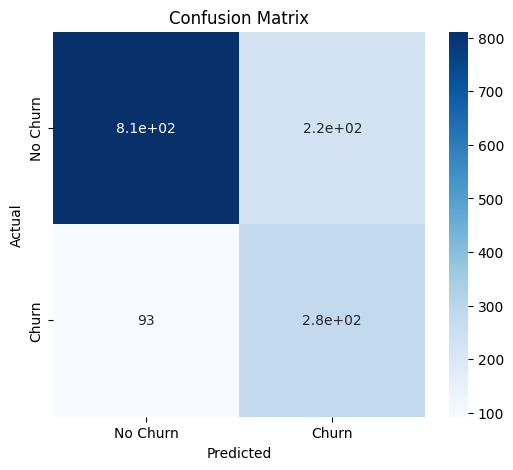

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# (B) Classification Report
Detailed precision, recall and F1 score for each class.

In [14]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


Precision : 0.5545
Recall    : 0.7507
F1 Score  : 0.6378
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.55      0.75      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



# (C) ROC AUC Score and Curve
AUC ROC measures overall model discrimination ability.
Score closer to 1.0 means better model performance.
Score of 0.5 means random guessing.

ROC-AUC Score : 0.8539


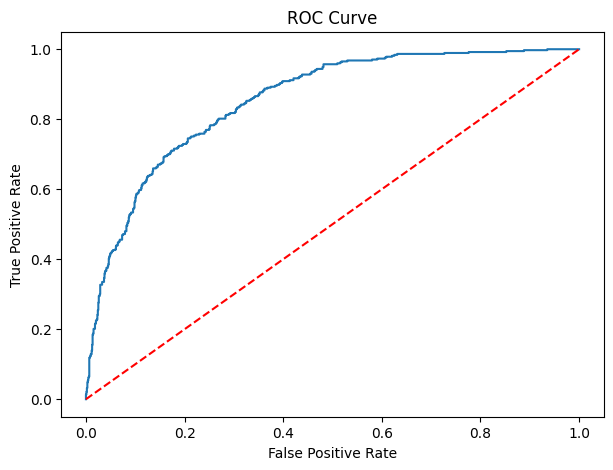

In [15]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score :", round(roc_auc,4))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# (D) Training History
Visualizing training and validation accuracy and loss
to check for overfitting or underfitting.


Accuracy: 0.7743080198722498


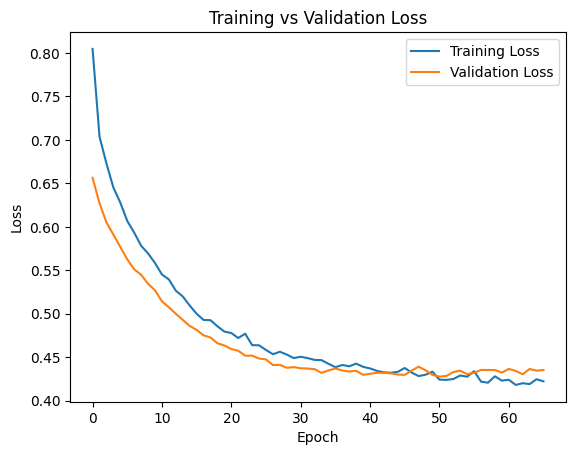

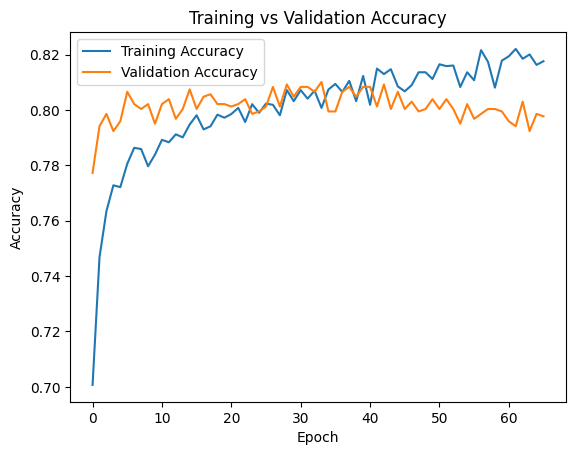

In [16]:
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()



In [17]:
# Save Model
model.save('churn_model.h5')

# Save Scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']